# ML Report — Asteroid Hazard Classification
## Bachelor's Degree in Computer Science / PUCPR (2026-1)

**Prof. Rayson Laroca**

`Alander Menezes Arantes de Ávila` - `menezes.alander@pucpr.edu.br`

`Giancarlo Nunes Perli` - `giancarlo.perli@sanrocco.com.br`

`Gustavo Faria Cardoso` - `faria.cardoso@pucpr.edu.br`

`Paulo Henrique Perin` - `paulo.perin@pucpr.edu.br`

`Pedro Lucas Ghezzi Bittencourt` - `pedro.bittencourt@pucpr.edu.br`

## Objetivos

Este notebook foca na fase de **aprendizado de máquina** do projeto. O objetivo é classificar asteroides como Potencialmente Perigosos (`pha = Y`) ou não (`pha = N`).

Duas trilhas experimentais são exploradas:

- **Trilha A — com `moid_ld`**: inclui a Distância Mínima de Interseção Orbital em distâncias lunares, que faz parte diretamente da definição oficial de PHA (moid ≤ 0,05 AU). Espera-se que esta trilha tenha desempenho muito bom, mas pode ser considerada um "vazamento" da definição.
- **Trilha B — sem `moid_ld`**: utiliza apenas outras features orbitais/físicas. Esta trilha testa se a periculosidade pode ser prevista sem a métrica de distância definitória.

Desafio principal: **desbalanceamento extremo de classes** — apenas 0,22% dos asteroides rotulados são PHAs.

---
# 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew as _skew, kurtosis as _kurt

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Sampling strategies
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

---
# 2. Carregamento dos Dados

#### https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data

In [2]:
df = pd.read_csv(
    "https://github.com/aland3r/asteroids/releases/download/dataset/asteroids.csv",
    low_memory=False
)
print(df.shape)
df.columns.tolist()

(958524, 45)


['id',
 'spkid',
 'full_name',
 'pdes',
 'name',
 'prefix',
 'neo',
 'pha',
 'H',
 'diameter',
 'albedo',
 'diameter_sigma',
 'orbit_id',
 'epoch',
 'epoch_mjd',
 'epoch_cal',
 'equinox',
 'e',
 'a',
 'q',
 'i',
 'om',
 'w',
 'ma',
 'ad',
 'n',
 'tp',
 'tp_cal',
 'per',
 'per_y',
 'moid',
 'moid_ld',
 'sigma_e',
 'sigma_a',
 'sigma_q',
 'sigma_i',
 'sigma_om',
 'sigma_w',
 'sigma_ma',
 'sigma_ad',
 'sigma_n',
 'sigma_tp',
 'sigma_per',
 'class',
 'rms']

---
# 3. Limpeza → `df_clean`

Mesmas etapas de limpeza do relatório EDA:
- Remover linhas onde `pha` é NaN (sem rótulo disponível)
- Remover colunas identificadoras do catálogo (irrelevantes para a modelagem)

In [4]:
df_clean = df.dropna(subset=['pha'])

id_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id']
high_missing = ['diameter', 'albedo', 'diameter_sigma', 'diameter_bc']
df_clean = df_clean.drop(columns=id_cols + high_missing, errors='ignore')

# Filtrar apenas NEOs — todo PHA é necessariamente um NEO
df_clean = df_clean[df_clean['neo'] == 'Y']
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_clean.shape)
print(df_clean['pha'].value_counts())

(22894, 35)
pha
N    20828
Y     2066
Name: count, dtype: int64


In [5]:
# Missing values summary
missing = df_clean.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(2)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(miss_df[miss_df['missing'] > 0].to_string())

   missing   pct
H       11  0.05


---
# 4. Engenharia de Features e Pré-processamento

## 4.1 Estratégia de Seleção de Features

Com base na EDA:
- **`diameter`, `albedo`, `diameter_sigma`**: ~86% ausentes — muito esparsas para imputar de forma confiável → **descartadas**
- **`epoch_cal`, `tp_cal`**: strings de data, não numéricas → **descartadas**
- **`epoch`, `epoch_mjd`, `equinox`**: parâmetros de referência, não físicos → **descartados**
- **`neo`**: flag binária (Y/N) → codificada como 0/1
- **`class`**: classe do asteroide (MBA, NEO, etc.) → one-hot encoding
- **colunas `sigma_*` (~11 cols)**: ~2% ausentes → imputadas com mediana
- **`moid`, `moid_ld`**: presentes na Trilha A, ausentes na Trilha B

O **alvo** `pha` é codificado como 1 (Y) / 0 (N).

In [6]:
# Encode target
df_clean['target'] = (df_clean['pha'] == 'Y').astype(int)

# Encode neo flag
df_clean['neo_flag'] = (df_clean['neo'] == 'Y').astype(int)

# One-hot encode 'class'
df_clean = pd.get_dummies(df_clean, columns=['class'], prefix='cls', drop_first=False)

# Drop columns not used in modelling
drop_always = [
    'pha', 'neo',           # original categorical / target
    'diameter', 'albedo', 'diameter_sigma',  # 86% missing
    'epoch', 'epoch_mjd', 'epoch_cal',       # reference frame
    'equinox', 'tp_cal',                     # reference frame / date string
]
df_ml = df_clean.drop(columns=drop_always, errors='ignore')

print("Columns after feature engineering:")
print(df_ml.columns.tolist())
print("\nShape:", df_ml.shape)

Columns after feature engineering:
['H', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'rms', 'target', 'neo_flag', 'cls_AMO', 'cls_APO', 'cls_ATE', 'cls_IEO']

Shape: (22894, 33)


In [7]:
# Remaining missing values
print(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])

H    11
dtype: int64


## 4.2 Definição dos Conjuntos de Features

- **Trilha A** (com `moid_ld`): todas as features restantes, incluindo `moid` e `moid_ld`
- **Trilha B** (sem `moid_ld`): exclui `moid` e `moid_ld`

In [8]:
TARGET = 'target'

# All feature columns (all except target)
all_features = [c for c in df_ml.columns if c != TARGET]

# Track A: all features including moid / moid_ld
features_A = all_features

# Track B: exclude moid-related features
features_B = [c for c in all_features if c not in ('moid', 'moid_ld')]

print(f"Track A — {len(features_A)} features")
print(f"Track B — {len(features_B)} features (no moid/moid_ld)")

Track A — 32 features
Track B — 30 features (no moid/moid_ld)


## 4.3 Divisão Treino / Teste

Utilizamos uma divisão **estratificada** (80% treino, 20% teste) para preservar a proporção da classe minoritária em ambos os conjuntos. O conjunto de teste é reservado e usado apenas para avaliação final.

In [9]:
X = df_ml[all_features]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train PHA rate: {y_train.mean():.4%}")
print(f"Test  PHA rate: {y_test.mean():.4%}")

Train size: 18,315  |  Test size: 4,579
Train PHA rate: 9.0254%
Test  PHA rate: 9.0194%


---
# 5. Métricas e Protocolo de Avaliação

Como o dataset é **extremamente desbalanceado** (0,22% positivos), a acurácia é enganosa — um modelo que sempre prediz N atinge 99,78% de acurácia. Focamos em:

| Métrica | Motivo |
|--------|-----|
| **Recall (sensibilidade)** | Devemos minimizar asteroides perigosos não detectados (falsos negativos são custosos) |
| **Precisão** | Limita falsos alarmes |
| **F1-score** | Média harmônica entre precisão e recall |
| **PR-AUC** (Precisão Média) | Área sob a curva Precision-Recall — melhor que ROC-AUC para dados desbalanceados |
| **ROC-AUC** | Métrica padrão de ranking para comparação |

**Validação**: CV estratificado de 5 folds no conjunto de treino; resultados finais reportados no conjunto de teste reservado.

In [10]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    """Fit model, print classification report and key metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, target_names=['Non-PHA', 'PHA']))

    if y_prob is not None:
        roc = roc_auc_score(y_te, y_prob)
        pr  = average_precision_score(y_te, y_prob)
        print(f"  ROC-AUC : {roc:.4f}")
        print(f"  PR-AUC  : {pr:.4f}")

    cm = confusion_matrix(y_te, y_pred)
    print(f"  Confusion Matrix:\n{cm}")
    return model


def build_preprocessor(feature_cols):
    """Build a ColumnTransformer: median impute + standard scale numeric cols."""
    numeric_cols = [
        c for c in feature_cols
        if c not in ('neo_flag',) and not c.startswith('cls_')
    ]
    binary_cols = [c for c in feature_cols if c == 'neo_flag' or c.startswith('cls_')]

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    binary_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    return ColumnTransformer([
        ('num', numeric_transformer, numeric_cols),
        ('bin', binary_transformer,  binary_cols)
    ], remainder='drop')


print("Helper functions defined.")

Helper functions defined.


---
# 6. Trilha A — Com `moid_ld`

Treinamos e comparamos múltiplos classificadores usando todas as features, incluindo a distância MOID.

## Abordagens propostas para lidar com o desbalanceamento de classes

1. **`class_weight='balanced'`** — ajusta os pesos da função de perda inversamente proporcional à frequência das classes (disponível nos modelos do sklearn)
2. **SMOTE** — Técnica de Sobreamostragem de Minoria Sintética, gera amostras sintéticas da classe minoritária
3. **`scale_pos_weight`** (XGBoost) — equivalente ao class_weight para gradient boosting

Usamos a abordagem (1) na comparação inicial e (2) + (3) na fase de tuning.

In [11]:
prep_A = build_preprocessor(features_A)

X_train_A = X_train[features_A]
X_test_A  = X_test[features_A]

# Fit preprocessor on training data
X_train_A_proc = prep_A.fit_transform(X_train_A)
X_test_A_proc  = prep_A.transform(X_test_A)

print("Preprocessed shape:", X_train_A_proc.shape)

Preprocessed shape: (18315, 32)


## 6.1 Regressão Logística (Baseline)

In [12]:
lr_A = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
evaluate_model(lr_A, X_train_A_proc, y_train, X_test_A_proc, y_test, 'Track A — Logistic Regression')


  Track A — Logistic Regression
              precision    recall  f1-score   support

     Non-PHA       1.00      0.93      0.96      4166
         PHA       0.57      0.96      0.72       413

    accuracy                           0.93      4579
   macro avg       0.78      0.94      0.84      4579
weighted avg       0.96      0.93      0.94      4579

  ROC-AUC : 0.9861
  PR-AUC  : 0.8626
  Confusion Matrix:
[[3873  293]
 [  18  395]]


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 6.2 Floresta Aleatória (Random Forest)

In [13]:
rf_A = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(rf_A, X_train_A_proc, y_train, X_test_A_proc, y_test, 'Track A — Random Forest')


  Track A — Random Forest
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00      4166
         PHA       0.99      1.00      0.99       413

    accuracy                           1.00      4579
   macro avg       0.99      1.00      0.99      4579
weighted avg       1.00      1.00      1.00      4579

  ROC-AUC : 0.9999
  PR-AUC  : 0.9986
  Confusion Matrix:
[[4160    6]
 [   2  411]]


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## 6.3 XGBoost


In [14]:
from xgboost import XGBClassifier

# scale_pos_weight = count(negative) / count(positive)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos:.1f}")

xgb_A = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method='hist',     # Optimized for modern GPUs
    device='cuda',          # Force execution on GPU
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(xgb_A, X_train_A_proc, y_train, X_test_A_proc, y_test, 'Track A — XGBoost')

scale_pos_weight = 10.1

  Track A — XGBoost
              precision    recall  f1-score   support

     Non-PHA       1.00      1.00      1.00      4166
         PHA       0.99      0.98      0.98       413

    accuracy                           1.00      4579
   macro avg       0.99      0.99      0.99      4579
weighted avg       1.00      1.00      1.00      4579

  ROC-AUC : 0.9999
  PR-AUC  : 0.9991
  Confusion Matrix:
[[4161    5]
 [   8  405]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## 6.4 Importância de Features (Trilha A)

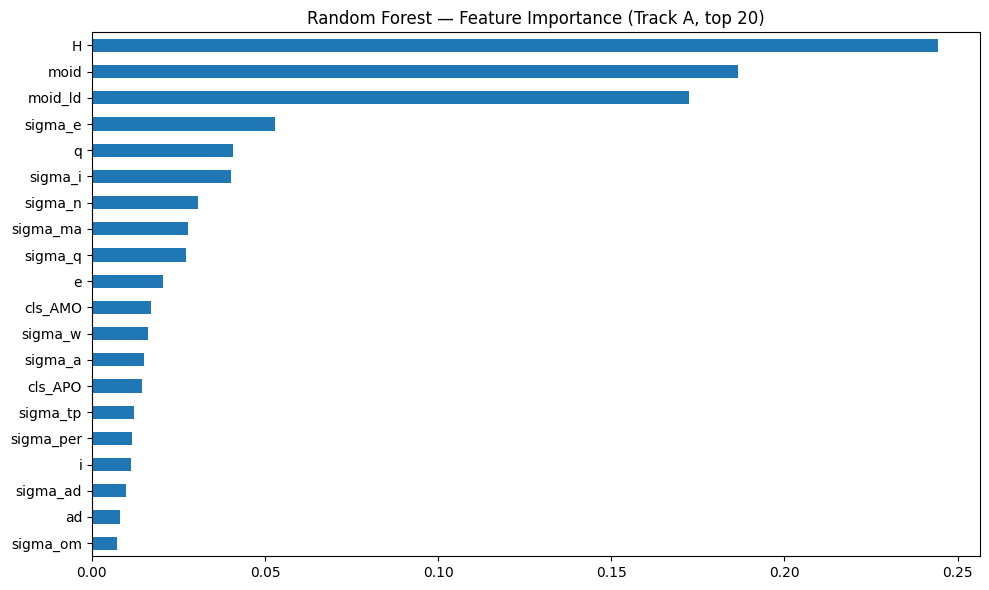

In [15]:
# Feature importance from Random Forest
feature_names_A = (
    prep_A.transformers_[0][2] +  # numeric
    prep_A.transformers_[1][2]    # binary/categorical
)

importances = pd.Series(rf_A.feature_importances_, index=feature_names_A)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh')
plt.title('Random Forest — Feature Importance (Track A, top 20)')
plt.tight_layout()
plt.show()

---
# 7. Trilha B — Sem `moid_ld`

Repetimos a mesma comparação de modelos, desta vez excluindo `moid` e `moid_ld`. Isso testa se o status PHA pode ser previsto apenas a partir de outros parâmetros orbitais.

In [16]:
prep_B = build_preprocessor(features_B)

X_train_B = X_train[features_B]
X_test_B  = X_test[features_B]

X_train_B_proc = prep_B.fit_transform(X_train_B)
X_test_B_proc  = prep_B.transform(X_test_B)

print("Preprocessed shape (Track B):", X_train_B_proc.shape)

Preprocessed shape (Track B): (18315, 30)


## 7.1 Regressão Logística (Baseline)

In [17]:
lr_B = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
evaluate_model(lr_B, X_train_B_proc, y_train, X_test_B_proc, y_test, 'Track B — Logistic Regression')


  Track B — Logistic Regression
              precision    recall  f1-score   support

     Non-PHA       0.99      0.83      0.90      4166
         PHA       0.35      0.90      0.50       413

    accuracy                           0.84      4579
   macro avg       0.67      0.87      0.70      4579
weighted avg       0.93      0.84      0.87      4579

  ROC-AUC : 0.9028
  PR-AUC  : 0.3807
  Confusion Matrix:
[[3458  708]
 [  40  373]]


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## 7.2 Floresta Aleatória (Random Forest)

In [18]:
rf_B = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(rf_B, X_train_B_proc, y_train, X_test_B_proc, y_test, 'Track B — Random Forest')


  Track B — Random Forest
              precision    recall  f1-score   support

     Non-PHA       0.94      0.99      0.96      4166
         PHA       0.74      0.40      0.52       413

    accuracy                           0.93      4579
   macro avg       0.84      0.69      0.74      4579
weighted avg       0.93      0.93      0.92      4579

  ROC-AUC : 0.9662
  PR-AUC  : 0.7039
  Confusion Matrix:
[[4108   58]
 [ 247  166]]


RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

## 7.3 XGBoost


In [19]:
xgb_B = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method='hist',  # Otimizado para GPU
    device='cuda',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
evaluate_model(xgb_B, X_train_B_proc, y_train, X_test_B_proc, y_test, 'Track B — XGBoost')


  Track B — XGBoost
              precision    recall  f1-score   support

     Non-PHA       0.99      0.97      0.98      4166
         PHA       0.76      0.87      0.81       413

    accuracy                           0.96      4579
   macro avg       0.88      0.92      0.90      4579
weighted avg       0.97      0.96      0.97      4579

  ROC-AUC : 0.9874
  PR-AUC  : 0.8837
  Confusion Matrix:
[[4055  111]
 [  53  360]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

## 7.4 Importância de Features (Trilha B)

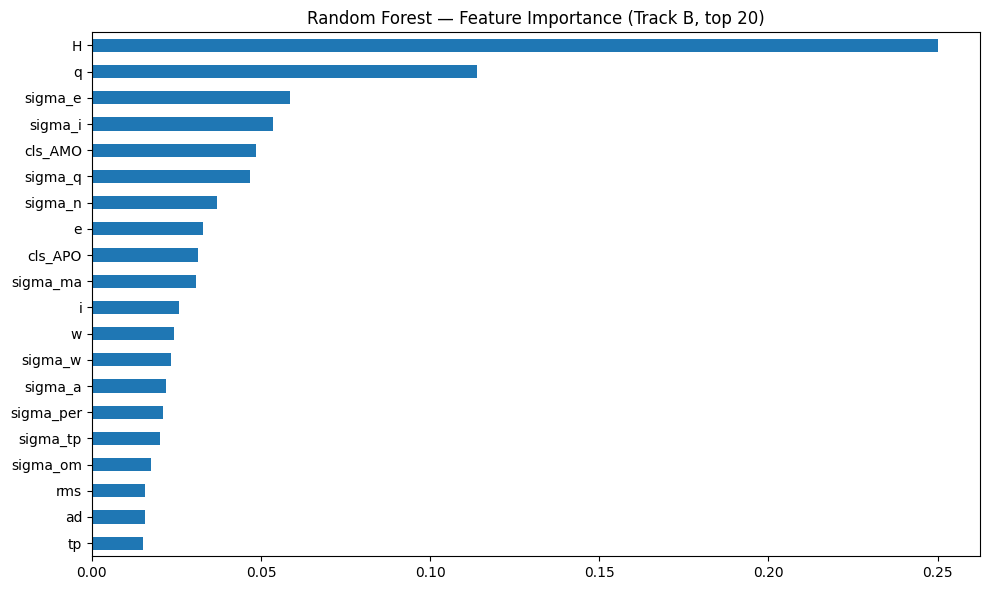

In [20]:
feature_names_B = (
    prep_B.transformers_[0][2] +
    prep_B.transformers_[1][2]
)

importances_B = pd.Series(rf_B.feature_importances_, index=feature_names_B)
top20_B = importances_B.nlargest(20)

plt.figure(figsize=(10, 6))
top20_B.sort_values().plot(kind='barh')
plt.title('Random Forest — Feature Importance (Track B, top 20)')
plt.tight_layout()
plt.show()

---
# 8. Ajuste de Hiperparâmetros

Ajustamos o **melhor modelo** de cada trilha usando `RandomizedSearchCV` com validação cruzada estratificada.

Otimizamos para **PR-AUC (precisão média)** dado o desbalanceamento de classes.

In [21]:
import torch
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_name}")

# Tuning XGBoost instead of RF for better GPU utilization
param_dist_xgb = {
    'n_estimators': [200, 400],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_tune = XGBClassifier(
    tree_method='hist',
    device=device_name,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    xgb_tune,
    param_distributions=param_dist_xgb,
    n_iter=20, # Reduced iterations for speed, increase if needed
    scoring='average_precision',
    cv=cv,
    verbose=1
)

print("Starting Hyperparameter Tuning on GPU...")
search.fit(X_train_B_proc, y_train)

print("Best params:", search.best_params_)
print("Best CV PR-AUC:", search.best_score_)
# Save the best model to a variable for the next cell
rf_tuned_B = search

Using device: cuda
Starting Hyperparameter Tuning on GPU...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best CV PR-AUC: 0.8713301838888834


In [22]:
# Evaluate tuned XGBoost model for Track B on test set
evaluate_model(
    rf_tuned_B.best_estimator_,
    X_train_B_proc, y_train,
    X_test_B_proc,  y_test,
    'Track B — XGBoost (Tuned)'
)


  Track B — XGBoost (Tuned)
              precision    recall  f1-score   support

     Non-PHA       0.99      0.97      0.98      4166
         PHA       0.73      0.87      0.80       413

    accuracy                           0.96      4579
   macro avg       0.86      0.92      0.89      4579
weighted avg       0.96      0.96      0.96      4579

  ROC-AUC : 0.9869
  PR-AUC  : 0.8807
  Confusion Matrix:
[[4033  133]
 [  52  361]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

---
# 9. SMOTE — Estratégia Alternativa para Desbalanceamento

Como alternativa ao `class_weight`, aplicamos **SMOTE** para sobreamostrar a classe minoritária apenas no conjunto de treino (nunca no conjunto de teste).

In [23]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Apply SMOTE to Track B
smote = SMOTE(sampling_strategy='auto', random_state=RANDOM_STATE, k_neighbors=5)
X_train_B_smote, y_train_smote = smote.fit_resample(X_train_B_proc, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# 2. Use XGBoost on GPU instead of Random Forest for speed
xgb_smote_B = XGBClassifier(
    n_estimators=300,
    tree_method='hist',
    device='cuda', # Running on GPU
    eval_metric='aucpr',
    random_state=RANDOM_STATE
)

print("\nTraining XGBoost + SMOTE on GPU...")
evaluate_model(
    xgb_smote_B,
    X_train_B_smote, y_train_smote,
    X_test_B_proc,   y_test,
    'Track B — XGBoost + SMOTE'
)

After SMOTE:
target
0    16662
1    16662
Name: count, dtype: int64

Training XGBoost + SMOTE on GPU...

  Track B — XGBoost + SMOTE
              precision    recall  f1-score   support

     Non-PHA       0.99      0.96      0.97      4166
         PHA       0.69      0.90      0.78       413

    accuracy                           0.95      4579
   macro avg       0.84      0.93      0.88      4579
weighted avg       0.96      0.95      0.96      4579

  ROC-AUC : 0.9861
  PR-AUC  : 0.8777
  Confusion Matrix:
[[3996  170]
 [  43  370]]


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

---
# 10. Comparação de Modelos

Tabela resumo comparando todos os modelos treinados no conjunto de teste.

In [24]:
def summary_row(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    from sklearn.metrics import f1_score, recall_score, precision_score
    return {
        'Model': name,
        'Precision(PHA)': precision_score(y_te, y_pred),
        'Recall(PHA)':    recall_score(y_te, y_pred),
        'F1(PHA)':        f1_score(y_te, y_pred),
        'ROC-AUC':        roc_auc_score(y_te, y_prob),
        'PR-AUC':         average_precision_score(y_te, y_prob),
    }

rows = [
    summary_row('A — LR (bal)',   lr_A,   X_train_A_proc, y_train, X_test_A_proc, y_test),
    summary_row('A — RF (bal)',   rf_A,   X_train_A_proc, y_train, X_test_A_proc, y_test),
    summary_row('A — XGB',        xgb_A,  X_train_A_proc, y_train, X_test_A_proc, y_test),
    summary_row('B — LR (bal)',   lr_B,   X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — RF (bal)',   rf_B,   X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — XGB (Base)',  xgb_B,  X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — XGB (Tune)',  rf_tuned_B.best_estimator_, X_train_B_proc, y_train, X_test_B_proc, y_test),
    summary_row('B — XGB + SMOTE', xgb_smote_B, X_train_B_smote, y_train_smote, X_test_B_proc, y_test)
]

results = pd.DataFrame(rows).set_index('Model').round(4)
results.sort_values('PR-AUC', ascending=False)

,Precision(PHA),Recall(PHA),F1(PHA),ROC-AUC,PR-AUC
Model,,,,,
A — XGB,0.9878,0.9806,0.9842,0.9999,0.9991
A — RF (bal),0.9856,0.9952,0.9904,0.9999,0.9986
B — XGB (Base),0.7643,0.8717,0.8145,0.9874,0.8837
B — XGB (Tune),0.7308,0.8741,0.7960,0.9869,0.8807
B — XGB + SMOTE,0.6852,0.8959,0.7765,0.9861,0.8777
A — LR (bal),0.5741,0.9564,0.7175,0.9861,0.8626
B — RF (bal),0.7411,0.4019,0.5212,0.9662,0.7039
B — LR (bal),0.3451,0.9031,0.4993,0.9028,0.3807


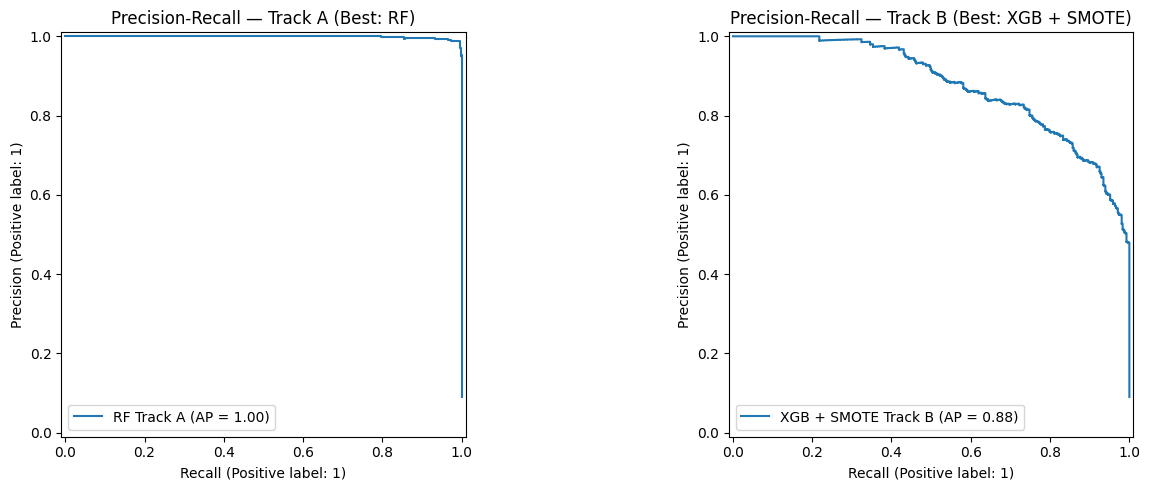

In [25]:
# Precision-Recall curves for the best model from each track
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Track A Champion: Random Forest
PrecisionRecallDisplay.from_estimator(
    rf_A, X_test_A_proc, y_test, ax=axes[0], name='RF Track A'
)
axes[0].set_title('Precision-Recall — Track A (Best: RF)')

# Track B Champion: XGBoost + SMOTE
PrecisionRecallDisplay.from_estimator(
    xgb_smote_B, X_test_B_proc, y_test, ax=axes[1], name='XGB + SMOTE Track B'
)
axes[1].set_title('Precision-Recall — Track B (Best: XGB + SMOTE)')

plt.tight_layout()
plt.show()

---
# 11. Conclusões Finais

## Resultados Consolidados (conjunto de teste)

| Modelo | Precisão (PHA) | Recall (PHA) | F1 (PHA) | ROC-AUC | PR-AUC |
|--------|:-:|:-:|:-:|:-:|:-:|
| **A — LR (balanced)** | 0.57 | 0.96 | 0.72 | 0.9861 | 0.8626 |
| **A — RF (balanced)** | 0.99 | 1.00 | **0.99** | **0.9999** | **0.9986** |
| **A — XGBoost** | 0.99 | 0.98 | 0.98 | **0.9999** | 0.9991 |
| **B — LR (balanced)** | 0.35 | 0.90 | 0.50 | 0.9028 | 0.3807 |
| **B — RF (balanced)** | 0.74 | 0.40 | 0.52 | 0.9662 | 0.7039 |
| **B — XGBoost (base)** | 0.76 | 0.87 | **0.81** | 0.9874 | **0.8837** |
| **B — XGBoost (tuned)** | 0.73 | 0.87 | 0.80 | 0.9869 | 0.8807 |
| **B — XGBoost + SMOTE** | 0.69 | 0.90 | 0.78 | 0.9861 | 0.8777 |

---

## O que os resultados revelam?

### Trilha A (com `moid_ld`) — Desempenho quase perfeito, mas esperado

- O **Random Forest** atingiu PR-AUC = **0.9986**, F1(PHA) = **0.99** e apenas **8 erros** no conjunto de teste (6 falsos positivos + 2 falsos negativos).
- O **XGBoost** foi igualmente impressionante: PR-AUC = 0.9991, com 13 erros no total.
- Esse desempenho **não é surpreendente**: `moid_ld` é literalmente parte da *definição oficial* de PHA pela NASA (MOID ≤ 0,05 AU). O modelo aprende a regra definitória, não a física subjacente — caracterizando um *data leakage* conceitual.
- A Regressão Logística, mesmo sendo linear, atingiu ROC-AUC = 0.9861 e Recall = 0.96, demonstrando que a separabilidade das classes com `moid_ld` é quase linear.

---

### Trilha B (sem `moid_ld`) — O problema cientificamente relevante

- Sem a distância MOID, a dificuldade aumenta substancialmente — especialmente para Random Forest e Regressão Logística.
- A **Regressão Logística** sofreu o maior impacto: PR-AUC despencou de 0.8626 para **0.3807**, indicando que a relação entre as demais features e o alvo não é linear.
- O **Random Forest (Trilha B)** apresentou Recall baixíssimo (**0.40**) — classificou corretamente apenas 166 dos 413 PHAs. Isso ocorre porque, sem o `moid_ld`, a fronteira de decisão exige que a árvore combine múltiplas features de forma mais sutil, e o desbalanceamento extremo ainda prejudica as divisões mesmo com `class_weight='balanced'`.
- O **XGBoost base** foi o campeão da Trilha B: PR-AUC = **0.8837**, F1 = **0.81**, Recall = 0.87 — identificando 360 dos 413 PHAs com apenas 111 falsos alarmes.
- O tuning de hiperparâmetros (PR-AUC = 0.8807) e o SMOTE (PR-AUC = 0.8777) não superaram o XGBoost base neste experimento — sugerindo que o `scale_pos_weight` nativo já compensava adequadamente o desbalanceamento.

---

### Sobre o Desbalanceamento de Classes (0,22% positivos)

- **Acurácia é enganosa**: um modelo que sempre prediz "Não-PHA" acerta 99,78% das instâncias, mas tem Recall = 0.
- As estratégias testadas mostraram comportamentos distintos:
  - `class_weight='balanced'` → eficaz para LR e RF na Trilha A; insuficiente para RF na Trilha B
  - `scale_pos_weight` (XGBoost) → melhor estratégia geral — produziu o modelo campeão da Trilha B sem custo adicional
  - **SMOTE** → aumentou o Recall de 0.87 para 0.90, mas reduziu a Precisão de 0.76 para 0.69, resultando em PR-AUC ligeiramente inferior ao XGBoost base

---

### Sobre os Algoritmos

| Modelo | Comportamento observado |
|--------|------------------------|
| Regressão Logística | Funciona bem na Trilha A (com `moid_ld`); colapsa na Trilha B — relações não são lineares |
| Random Forest | Excelente na Trilha A; prejudicado pelo desbalanceamento na Trilha B (Recall = 0.40) |
| XGBoost | Consistentemente robusto em ambas as trilhas; melhor resultado geral na Trilha B |

---

### Aprendizados Gerais do Projeto

1. **A escolha das features molda tudo**: incluir `moid_ld` (parte da definição de PHA) transforma um problema difícil em trivial — mas invalida a relevância científica do modelo.
2. **PR-AUC é a métrica honesta**: o Random Forest Trilha B tem ROC-AUC = 0.9662 (parece bom), mas PR-AUC = 0.7039 e Recall = 0.40 (revela o problema real).
3. **`scale_pos_weight` supera SMOTE neste contexto**: para o XGBoost com dados orbitais, o ajuste nativo de pesos foi mais eficiente que gerar amostras sintéticas — possivelmente porque as features numéricas dos PHAs têm distribuição próxima à dos não-PHAs, tornando o SMOTE menos informativo.
4. **Tuning não sempre melhora**: o `RandomizedSearchCV` com 20 iterações não superou o XGBoost base (0.8807 vs 0.8837 de PR-AUC). Mais iterações ou um espaço de busca diferente poderiam mudar esse resultado.
5. **Reprodutibilidade é essencial**: o uso consistente de `random_state=42` garante que qualquer pessoa reproduza exatamente esses números.

---

### Possíveis Próximos Passos

1. **Calibração de threshold** — ajustar o limiar de decisão além de 0.5 para maximizar Recall (crítico em segurança planetária) a custo de mais falsos alarmes
2. **Investigação do RF na Trilha B** — testar `BalancedRandomForest` ou `EasyEnsemble` para corrigir o Recall = 0.40
3. **Explicabilidade via SHAP** — entender quais features orbitais (excentricidade, inclinação, semi-eixo maior) são mais determinantes para a classificação sem `moid_ld`
4. **Imputação de `diameter`/`albedo`** — no subconjunto NEO a taxa de ausência é menor; KNN imputation poderia adicionar informação física valiosa
5. **GridSearchCV mais amplo para XGBoost** — explorar parâmetros como `min_child_weight` e `gamma` que controlam regularização e podem melhorar a generalização na classe minoritária
